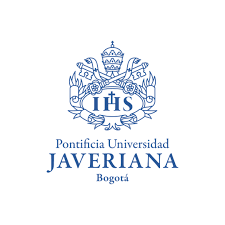
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autores: Jorge Gomez

Fecha de Inicio: 13/04/2026

Fecha actual: 27/04/2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

_______________________________________________________________________________________________________________________________________________________

## **1.- Importación de bibliotecas**

In [1]:
# Levantamiento de variables de entorno pip
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

In [2]:
### Levantamiento de sesión SPARK
configura = SparkConf()

configura.setAppName("Calidad_Agua_S")

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

sparkContextoS = sparkS.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkS

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 08:23:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


In [3]:
##**2.- Carga de Datos desde el HADOOP HDFS**

!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkS.read.format("csv").option("header", "true").load("waterquality.csv")

df00.show(5)

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


[Stage 1:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **Conclusión: importacion de bibliotecas.**
Se importan las librerias necesarias para cumplir el proceso de analisis, activamos una secion en SPARK llamada sparkS y finalmente se llama a la base de datos y compru que se haya importado la base, mostramos las 5 primeras lineas de la base de datos.

_______________________________________________________________________________________________________________________________________________________

## **2.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

### **Tratamiento de datos**

In [4]:
df00.dtypes

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'string'),
 ('DO', 'string'),
 ('pH', 'string'),
 ('CONDUCTIVITY', 'string'),
 ('BOD', 'string'),
 ('NITRATE_N_NITRITE_N', 'string'),
 ('FECAL_COLIFORM', 'string'),
 ('TOTAL_COLIFORM', 'string')]


### Se procede a cambiar los tipos de datos


In [5]:
df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
df00.dtypes

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'float'),
 ('DO', 'float'),
 ('pH', 'float'),
 ('CONDUCTIVITY', 'float'),
 ('BOD', 'float'),
 ('NITRATE_N_NITRITE_N', 'float'),
 ('FECAL_COLIFORM', 'float'),
 ('TOTAL_COLIFORM', 'string')]

### **Conocimiento de las columnas**

In [6]:

df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

### Se presenta las estadísticas de los datos a continuación:


In [7]:

for valor in df00.columns:
  
  df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+



+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               529|
|   mean|25.241398822157056|
| stddev|3.4480130774354945|
|    min|              10.5|
|    max|              33.8|
+-------+------------------+

+-------+------------------+
|summary|                DO|
+-------+------------------+
|  count|               532|
|   mean|  6.38981203334336|
| stddev|1.6228617240309144|
|    min|               0.0|
|    max|              16.3|
+-------+------------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean| 7.798127372613114|
| stddev|0.6499503850220179|
|    min|               6.3|
|    max|              14.7|
+-------+---------

[Stage 32:>                                                         (0 + 1) / 1]

+-------+------------------+
|summary|    TOTAL_COLIFORM|
+-------+------------------+
|  count|               534|
|   mean|124396.96767676767|
| stddev|1458407.8189939584|
|    min|                 1|
|    max|                NA|
+-------+------------------+



In [8]:
df01 = df00
df01.createOrReplaceTempView("df01_sql")

### **Visualización de los datos nulos**


### Cantidad de valores nulos o imposibles

In [9]:

df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   5|  2|  0|          30|  6|                  2|            82|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



* Se verifica la Cantidad de Valores Nulos o Imposibles
* Se procede a Graficar cada una de las dimensiones
### Se crea una vista para ser usada en las visualizaciones

In [10]:
df00.createOrReplaceTempView("df00_sql")
df01 = sparkS.sql('''Select * from df00_sql where TEMP is not null and
  
             DO is not null and
             pH is not null and
             CONDUCTIVITY is not null and
             BOD is not null and
             NITRATE_N_NITRITE_N is not null and
             FECAL_COLIFORM is not null''')

### Se verifica la cantidad de valores nulos o imposibles

In [11]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### Se elimina la columna TOTAL_COLIFORM

In [12]:
df01 = df00.drop('TOTAL_COLIFORM')
df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

### **Creación de Tablas para Visualizar los Datos**

### Se crea una consulta por cada parámetro

In [13]:
do_parametro = sparkS.sql("Select DO from df01_sql")
ph_parametro = sparkS.sql("Select PH from df01_sql")
BOD_parametro = sparkS.sql("Select BOD from df01_sql")
NN_parametro = sparkS.sql("Select NITRATE_N_NITRITE_N from df01_sql")
COND_parametro = sparkS.sql("Select CONDUCTIVITY from df01_sql")
FC_parametro = sparkS.sql("Select FECAL_COLIFORM from df01_sql")

### Se hace una consulta para crear el vector de la tabla por cada parámetro
Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

In [14]:
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.PH).collect()
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()
NN_parametro = NN_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()
COND_parametro = COND_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()
FC_parametro = FC_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()

### **Grafica Los parámetros para conocer sus características: DO y PH**

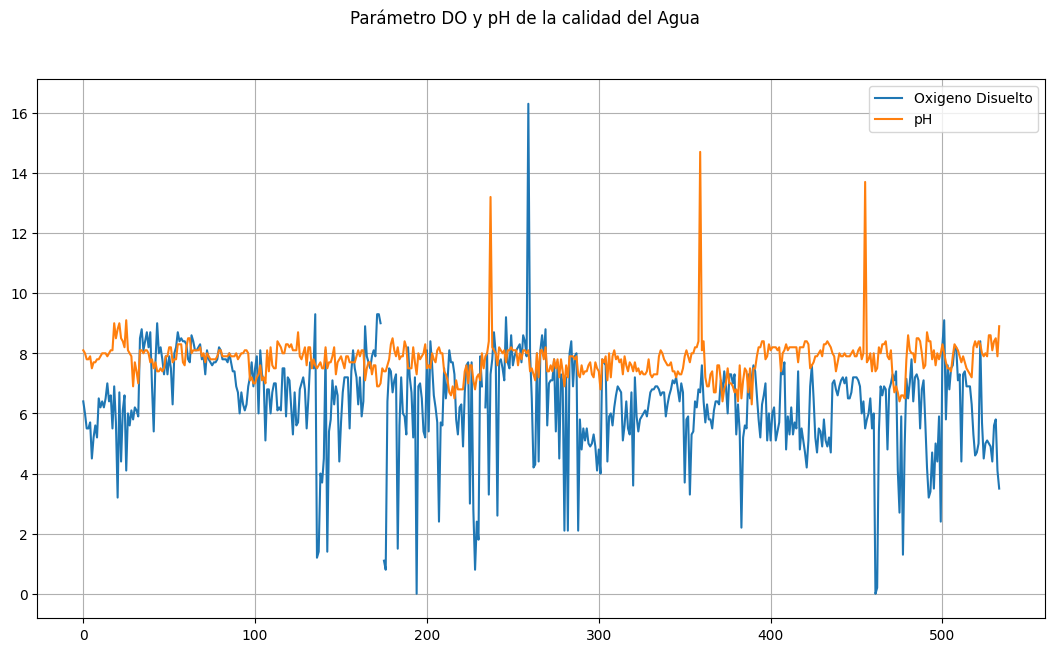

In [15]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='pH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

El análisis evidencia que el pH se mantiene relativamente estable en rangos neutros a ligeramente alcalinos, lo que sugiere ausencia de alteraciones químicas significativas. Sin embargo, el oxígeno disuelto presenta alta variabilidad y valores bajos en varias muestras, lo cual indica posibles procesos de contaminación orgánica que afectan la calidad del agua. En conjunto, se concluye que, aunque el pH no muestra problemas relevantes, la disponibilidad de oxígeno podría comprometer las condiciones del ecosistema acuático.

### **Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos**

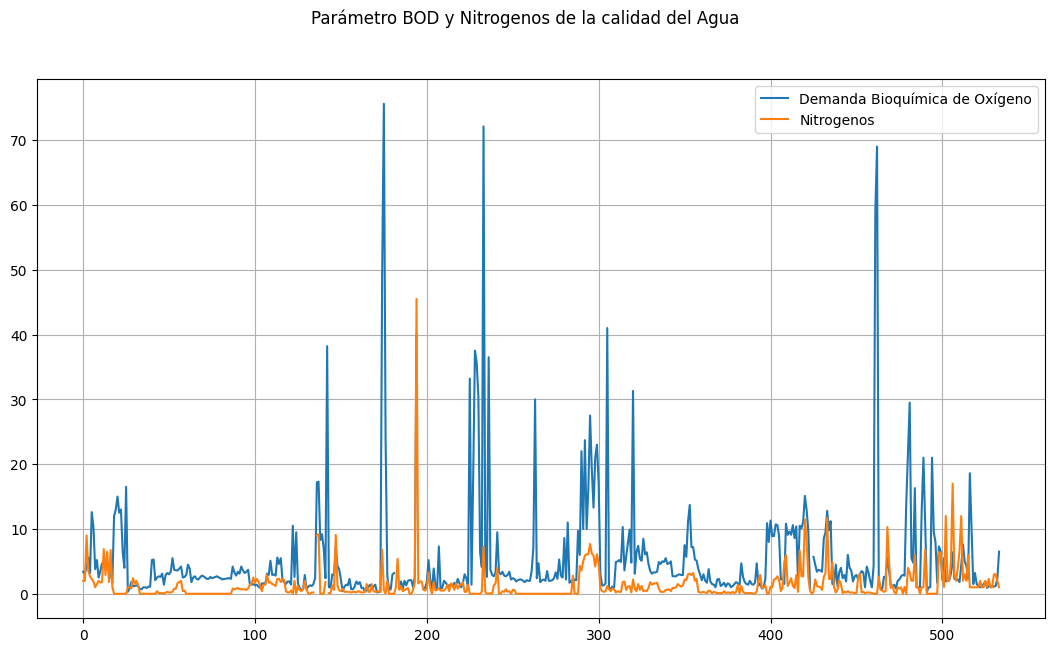

In [16]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), BOD_parametro, label='Demanda Bioquímica de Oxígeno')
ax1.plot(range(0,tam), NN_parametro, label='Nitrogenos')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

La gráfica muestra que tanto la BOD como los compuestos nitrogenados presentan alta variabilidad a lo largo de las muestras. Se observan picos elevados en la BOD, lo que indica presencia de materia orgánica, mientras que los nitratos y nitritos, aunque generalmente bajos, presentan incrementos puntuales. Estos comportamientos sugieren episodios de contaminación que pueden afectar la calidad del agua.

### **Grafica Los parámetros para conocer sus características: FC y Conductividad**

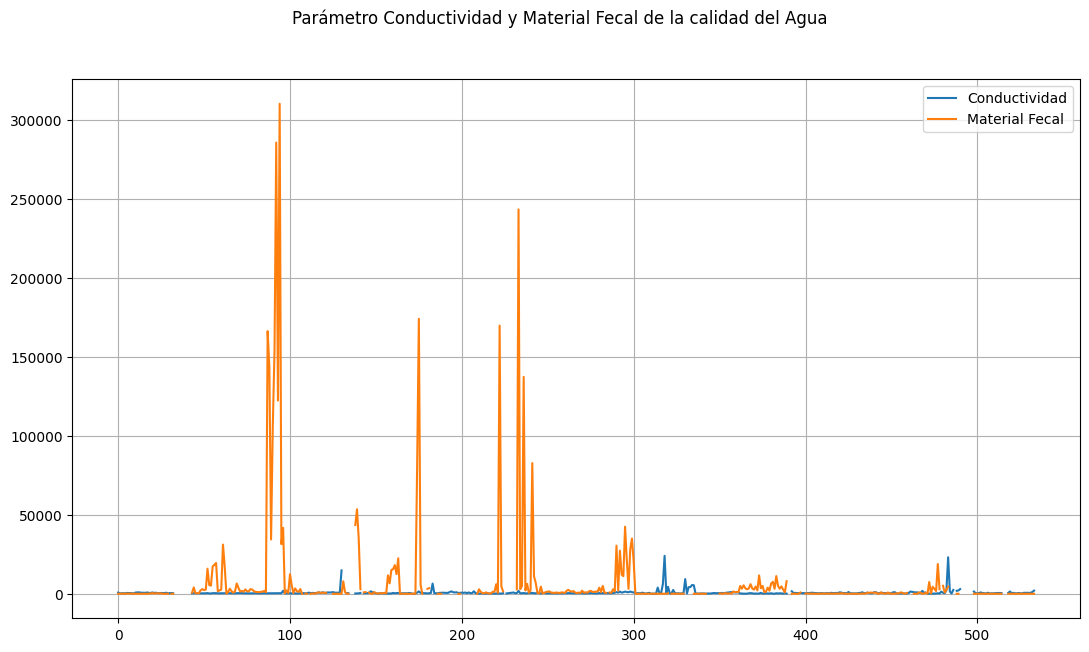

In [17]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
ax1.plot(range(0,tam), FC_parametro, label='Material Fecal')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

La gráfica muestra que tanto la conductividad como la concentración de material fecal presentan alta variabilidad a lo largo de las muestras. Se observan picos extremadamente altos en el material fecal, lo que indica posibles episodios de contaminación significativa, mientras que la conductividad presenta incrementos más moderados. Estos patrones sugieren la presencia de fuentes de contaminación que afectan la calidad del agua de manera puntual.

* Función para definir el rango de calidad de agua según el pH.
 Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)+
    *  100: Agua Dulce
    *  80: Agua Moderada
    *  60: Agua Dura
    *  40: Agua muy Dura

In [18]:


 df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

* Función para definir el rango de la calidad del agua según DO
    *  100: Agua Dulce
    *  80: Agua Moderada
    *  60: Agua Dura
    *  40: Agua muy Dura

In [19]:
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
                    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
                    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
                    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

* Función para definir el rango de la calidad del agua según COND
    *  100: Agua Dulce
    *  80: Agua Moderada
    *  60: Agua Dura
    *  40: Agua muy Dura

In [20]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
          when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
          when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
          when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

* Función para definir el rango de la calidad del agua según BOD
    *  100: Agua Dulce
    *  80: Agua Moderada
    *  60: Agua Dura
    *  40: Agua muy Dura

In [21]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
                     when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
                     when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
                     when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

*  Función para definir el rango de la calidad del agua según NITRATE_N_NITRITE_N
    *  100: Agua Dulce
    *  80: Agua Moderada
    *  60: Agua Dura
    *  40: Agua muy Dura

In [22]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
                     when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
                     when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
                     when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

*  Función para definir el rando de la calidad del agua según el Material Fecal
    *   100: Agua Dulce
    *   80: Agua Moderada
    *   60: Agua Dura
    *   40: Agua muy Dura

In [23]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
                    when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
                    when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
                    when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

 El objeto dataframe **df02**, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua
 ### A continuación se hace una inspección en general del df02


In [24]:
df02.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

### Nombre de Columnas

In [25]:
df02.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

### **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**



### Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

In [26]:
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

In [27]:
df03.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

In [28]:
df03.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

   

In [29]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***


In [30]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
 .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
 .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
 .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
 .otherwise('Inadecuada')
                      )
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

### Impresión de nombre de regiones sobre el mapa

In [31]:
colEstado = 'STATE'
valNomnbres = df05.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**

- Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta



In [32]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [33]:
import geopandas as gpd

rutaMapas = "Indian_States/Indian_States.shp"


- ### Se carga un objeto dataframe de los datos comprimidos de los mapas


In [34]:
gpd01 = gpd.read_file(rutaMapas)

- ### Se visualiza el tipo de dataframe que da geopandas y las columnas 


In [35]:
print(type(gpd01))

gpd01.columns

<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

- ### Se visualizan los nombres de la columna de los estados "st_nm"

In [36]:
gpd01["st_nm"].unique()

array(['Andaman & Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara & Nagar Havelli',
       'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Andhra Pradesh'], dtype=object)


- ###  Se procede a eliminar caracteres irregulares:
la idea es que los estados del mapa coincidan con los nombres de los estados del dataframe de datos inicial


In [37]:

gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                     'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                    'Daman & Diu': 'Daman Diu', 
                     'Jammu & Kashmir': 'Jammu Kashmir',
                     'NCT of Delhi' : 'Delhi'
                      })
gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

### Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

*  Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark

In [38]:
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

-  Se deja todo en letra Capital en el df spark

In [39]:
df06 = df06.withColumn('STATE', F.initcap('STATE'))

-  Inspección ocular del cambio

In [40]:
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

- Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"

In [41]:
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

- Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"

In [42]:
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

-  Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)

In [43]:
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

- Se eliminan los puntos duplicados

In [44]:
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

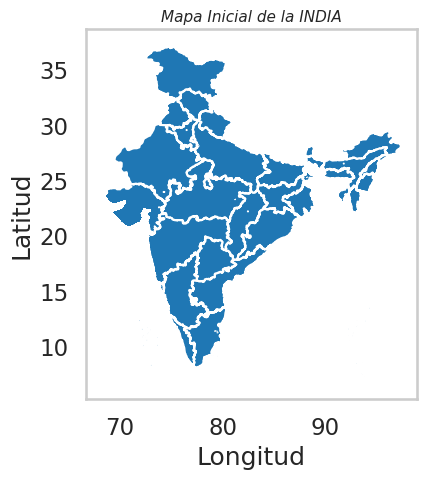

In [64]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()


Primero, se realiza un ajuste estructural de los datos, donde se renombra la columna "st_nm" a "STATE". Esto no es trivial: permite estandarizar los nombres de las claves entre distintos datasets, lo cual es fundamental para evitar errores en la integración posterior.

Luego, se lleva a cabo la integración de datos mediante un merge entre dos fuentes: un GeoDataFrame (mapa) y un DataFrame convertido desde Spark. El uso de un outer join indica que se quiere conservar toda la información de ambas fuentes, incluso si hay estados que no coinciden perfectamente entre sí. Esto puede ser útil para análisis exploratorios, pero también puede introducir valores nulos que luego deberán manejarse.

En la siguiente etapa, se aborda un problema geométrico importante: cómo representar cada región en un punto. Para esto, se utilizan los puntos representativos (representative_point), que garantizan que el punto esté dentro de la geometría del estado. Esto es más robusto que usar centroides en regiones con formas irregulares. Posteriormente, se extraen las coordenadas de estos puntos para facilitar visualizaciones o análisis adicionales.

Después, se realiza una limpieza de datos, eliminando duplicados basados en la columna "STATE". Esto asegura que cada estado tenga una única representación, lo cual es crucial para evitar inconsistencias en el mapa final.

Finalmente, se construye una visualización inicial del mapa, donde:

Se grafican los estados.
Se asigna un color gris claro a los datos faltantes.
Se añaden etiquetas de ejes (longitud y latitud) y un título descriptivo.

Este mapa inicial cumple una función exploratoria: permite verificar visualmente que la unión de datos fue correcta y que las geometrías están bien definidas.

En conjunto, el proceso refleja buenas prácticas en ciencia de datos geoespaciales: limpieza, integración, transformación geométrica y visualización. Sin embargo, un posible punto de mejora sería validar los valores nulos generados en el merge y considerar un tipo de unión más restrictivo (inner) si se busca consistencia total entre datasets.

In [47]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)

In [48]:
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

### **Impresión del mapa con seaborn**

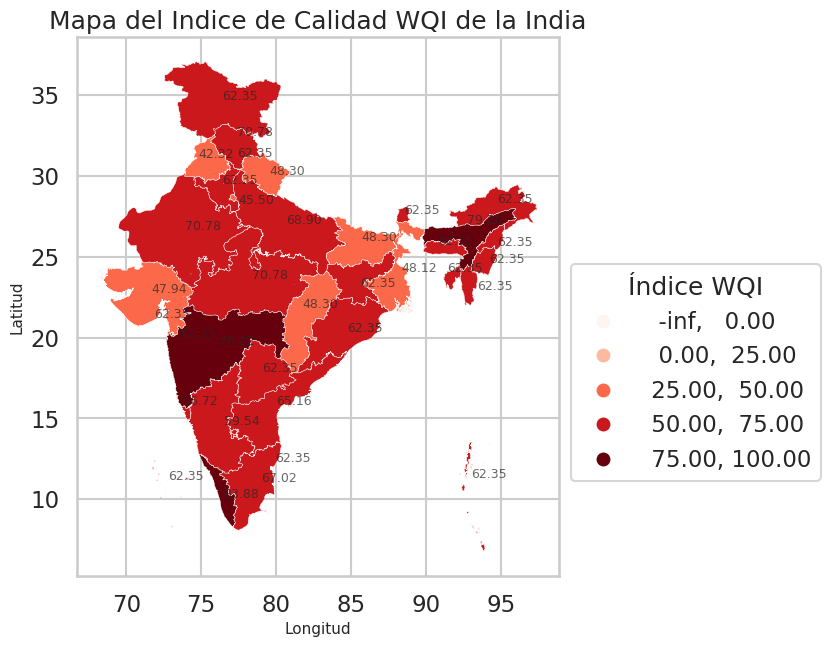

In [49]:
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

Este segundo mapa representa una evolución clara respecto al mapa inicial, ya que ahora no solo muestra la geometría de los estados de la India, sino que incorpora una variable cuantitativa: el Índice de Calidad del Agua (WQI). Esto lo convierte en un mapa temático (coroplético), útil para análisis más profundos.

Desde el punto de vista analítico, hay varios aspectos importantes:

En primer lugar, el mapa ya permite identificar patrones espaciales. Se observa que gran parte del territorio presenta valores en rangos medios-altos (50–75), mientras que algunas zonas, especialmente en el sur y ciertas regiones centrales, alcanzan valores más altos (75–100), indicados con tonos más oscuros. Esto sugiere una mejor calidad del agua en esas regiones, aunque habría que contrastarlo con datos reales o contexto ambiental.

También se evidencian zonas con valores más bajos (25–50), especialmente hacia el oeste o algunas áreas del centro. Esto podría indicar regiones con problemas de calidad del agua, lo cual es clave para toma de decisiones en políticas públicas o gestión ambiental.

Un punto fuerte es el uso de una escala de colores (rojos) bien segmentada por rangos, lo que facilita la interpretación rápida. Sin embargo, el uso exclusivo de tonos rojos puede generar ambigüedad, ya que intuitivamente el rojo suele asociarse con “malo”, pero aquí representa todo el espectro. Una mejora sería usar una paleta divergente (por ejemplo, verde → amarillo → rojo) para mayor claridad semántica.

La inclusión de valores numéricos sobre cada estado añade precisión, pero también recarga visualmente el mapa, especialmente en estados pequeños o cercanos. Esto puede dificultar la lectura. Una alternativa más limpia sería usar tooltips interactivos (si se trabaja en entorno web) o reducir la cantidad de etiquetas.

Otro detalle relevante es que el mapa sigue usando coordenadas geográficas (latitud/longitud) sin reproyección. Para visualización general está bien, pero para análisis más avanzados (áreas, distancias) sería mejor usar una proyección adecuada.

Finalmente, la leyenda está bien estructurada, pero el rango “-inf, 0.00” sugiere que hay datos faltantes o valores inválidos. Esto debería revisarse, ya que puede indicar problemas en el preprocesamiento de datos.

En conclusión, este mapa ya cumple una función analítica real: permite detectar patrones regionales en la calidad del agua. No obstante, aún puede mejorar en visualización, limpieza de datos y elección de escala de colores para ser más claro y profesional.

### **Histograma de WQI por Estado**

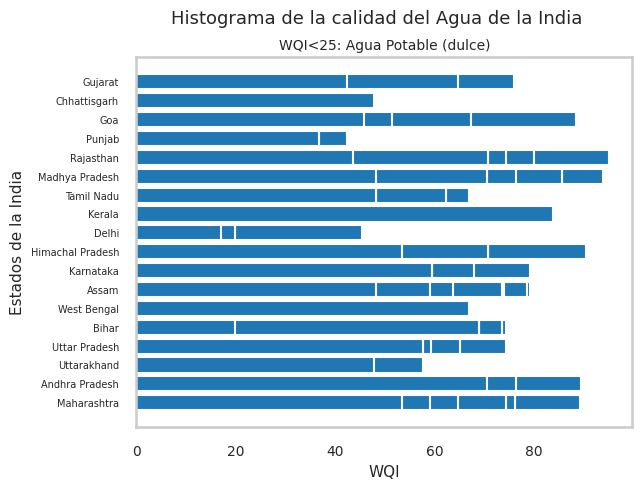

In [50]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkS.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkS.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

El histograma muestra la distribución del índice de calidad del agua (WQI) en diferentes estados de la India. Se observa que la mayoría de los valores se encuentran por encima de 25, lo que indica que gran parte del agua no se clasifica como potable según este criterio. Sin embargo, algunos estados presentan valores más bajos, lo que sugiere mejores condiciones de calidad. En general, los resultados evidencian variabilidad entre regiones y posibles diferencias en los niveles de contaminación del agua.

## **Conclusiones: Análisis y Preparación de Datos.**
1. La primera parte desarrollada en esta sección se basó principalmente en la modificación de los datos presentes en la base de datos, los cuales serían utilizados para realizar las visualizaciones, cambiando su tipo de dato de string o texto a valores flotantes o números decimales.
   Posteriormente, se visualizaron valores específicos de cada columna de datos, como la media, la desviación estándar, la cantidad, el valor máximo y el valor mínimo, con el fin de obtener una visión general de todo el contenido de los datos.
   Una vez hecho esto, se procedió a revisar la presencia de datos faltantes o imposibles, con el objetivo de modificarlos o corregirlos para las posibles visualizaciones.
   Con los datos ya procesados, se creó una vista con ayuda de código tipo SQL que permite visualizar únicamente datos válidos, eliminando valores imposibles o erróneos. Esto se logró mediante instrucciones en formato SQL que seleccionan todos los valores de una columna, exceptuando aquellos que son nulos. A esta vista se le define como df02.

   Finalmente, en esta visualización se eliminó la columna Total_Coliform, ya que no tiene utilidad para la investigación que se está realizando.

3. Después de esto, se preparan los datos para realizar las visualizaciones. Se toma una cantidad reducida de datos, enfocándose principalmente en aquellos relacionados con las características del agua. A partir de esto, se genera una consulta específica para cada conjunto de datos, con el fin de determinar qué información se debe representar en cada gráfica.

   Posteriormente, se elaboran visualizaciones concretas de pares de variables, con el objetivo de analizar cómo varían en función de la cantidad de datos. La primera gráfica relaciona el pH y el oxígeno disuelto; la segunda, la concentración química de oxígeno y el nitrógeno; y la tercera, el material fecal y la conductividad.

4. Con lo anterior realizado, se procede a generar los rangos que definen la calidad del agua según cada variable o columna, como por ejemplo el pH. Esta nueva tabla, que contiene dichos rangos, se define como df02.

   Una vez establecidos los rangos, se procede a calcular el índice de calidad tomando estos valores como referencia y basándose nuevamente en cada una de las columnas determinadas. A esta nueva tabla se le denomina df03.

   A continuación, se calcula el WQI (índice de calidad del agua), realizando la sumatoria de los índices obtenidos para cada uno de los valores por separado. El resultado de este proceso da lugar a una nueva tabla, definida como df04.

   Posteriormente, este valor se transforma en una interpretación cualitativa de la calidad del agua. Por ejemplo, si el WQI supera el valor de 100, se puede clasificar el agua como residual. A esta nueva tabla, que incorpora esta clasificación, se le denomina df05.

   Finalmente, se procede a la etapa de visualización, que consiste en representar estos resultados en un mapa de la India. Para ello, primero se utiliza Geopandas junto con una base de datos que contiene la división por estados del país. Con esto se genera el mapa base y, posteriormente, se integran los datos procesados para mostrar los índices de calidad del agua, representándolos mediante la intensidad del color en cada región.

   Como complemento, también se realiza un histograma que permite analizar la distribución de la calidad del agua de manera general.

_______________________________________________________________________________________________________________________________________________________

## **3.- Creación de Modelo: Calidad de Agua en la India**
Se requiere predecir el parámetro WQI
    
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

- ### Preparación de datos para la predicción del WQI

In [51]:
dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

- ### Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

In [52]:

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [53]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


- ### Se importa el Keras y la instancia TensorFlow

In [54]:
!pip install keras
!pip install tensorflow
import keras
from keras.models import Sequential
from keras.layers import Dense

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


2026-04-27 08:25:21.761567: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 08:25:21.910996: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 08:25:24.746647: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Se ajustan las variables: El ajuste es de forma estandar.
Se requiere un estudio profundo sobre el
ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
académica.


In [55]:
epocas = 200
lote = 81

- ### Se inicializa el modelo con las capas

In [56]:
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-27 08:25:25.308415: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


- ### Para optimizar el modelo se usa el optimizador ADAM. La compilación se ajusta a la pérdida del error cuadrático

In [57]:

keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [58]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1189.9825 - mse: 1189.9825
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 181.1048 - mse: 181.1048 
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 53.3092 - mse: 53.3092
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.4408 - mse: 22.4408
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13.0172 - mse: 13.0172
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.1506 - mse: 6.1506 
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.7328 - mse: 2.7328 
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.4894 - mse: 1.4894 
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9754 - mse: 0.9754 
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6196 - mse: 0.6196 
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3443 - mse: 0.3443 
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2736 - mse: 0.2736 
Epoch 13/200
6/6 ━━━━━━━━━━━━━━━━━━

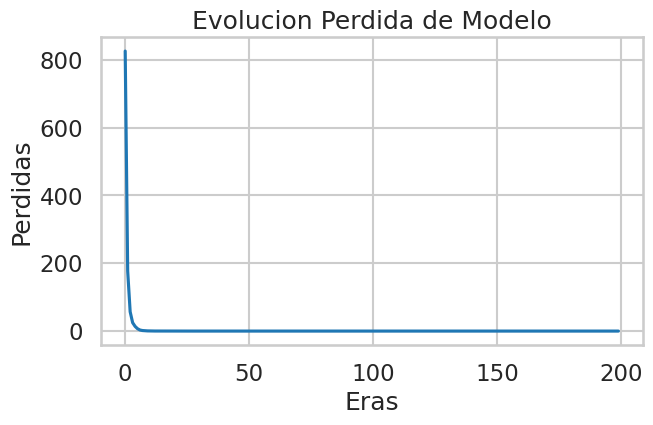

In [60]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("Evolucion Perdida de Modelo")
plt.xlabel("Eras")
plt.ylabel("Perdidas")
plt.show()

La gráfica muestra la evolución de la pérdida del modelo a lo largo de las épocas de entrenamiento. Se observa una disminución rápida de la pérdida en las primeras iteraciones, seguida de una estabilización en valores cercanos a cero. Este comportamiento indica que el modelo aprende de manera eficiente y converge adecuadamente durante el entrenamiento.

- ### Predicción sobre los datos del entrenamiento

In [61]:
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


### Se pinta la predicción

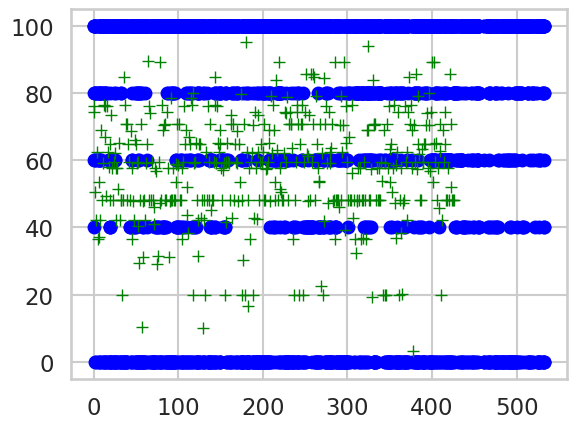

In [62]:
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
plt.show()

La gráfica muestra la distribución de valores en diferentes muestras, donde se observan agrupaciones en niveles específicos, lo que sugiere que algunos datos han sido discretizados o clasificados en rangos definidos. Además, se evidencia dispersión en los valores intermedios, indicando variabilidad en los datos. Este comportamiento permite identificar patrones y posibles concentraciones de valores dentro de ciertos intervalos.

##  **Conclusión: Creacion y evaluación del modelo.**
El modelo de regresión implementado muestra una capacidad sólida para capturar la tendencia general de la calidad del agua en la India. La comparación visual entre los datos de entrenamiento y las predicciones, indica que el modelo sigue los patrones de concentración de valores en rangos específicos, lo que sugiere un aprendizaje efectivo de las clasificaciones o discretizaciones presentes en los datos originales.

Metodológicamente se contempla la evaluación del modelo como una etapa posterior, sin embargo, en este cuaderno la evaluación del modelo se aborda de manera implícita a través del análisis del comportamiento del modelo durante el entrenamiento. El modelo de red neuronal implementado para la predicción del índice de calidad del agua (WQI) demuestra un desempeño adecuado durante la fase de entrenamiento. A partir de la evolución de la función de pérdida (MSE), se evidencia una disminución significativa en las primeras épocas, lo que indica que el modelo logra capturar rápidamente las relaciones subyacentes entre las variables de entrada.

Posteriormente, la pérdida tiende a estabilizarse en valores bajos, lo que sugiere que el modelo ha alcanzado un punto de convergencia y ha aprendido patrones relevantes sin presentar oscilaciones abruptas. Este comportamiento sugiere un entrenamiento exitoso.

En términos generales, el modelo construido con Keras y optimizado mediante el algoritmo Adam cumple con el objetivo de aproximar el valor del WQI, mostrando una buena capacidad de aprendizaje.

## **Referencias**
[1] Sutadian, A. D., et al. (2016). Development of a water quality index for rivers in West Java Province, Indonesia. IntechOpen, Chapter 69568. https://www.intechopen.com/chapters/69568
[2] Central Pollution Control Board India — National Water Quality Monitoring Programme (RiverIndia Dataset).
[3] Apache Spark MLlib Documentation. https://spark.apache.org/docs/latest/ml-guide.html
[4] Chollet, F. (2021). Deep Learning with Python, 2nd Edition. Manning Publications.
[5] Corredor, J. (2026). Material de clase: Procesamiento de Alto Volumen de Datos. Pontificia Universidad Javeriana, Bogotá.

_______________________________________________________________________________________________________________________________________________________